In [5]:
import sys 
import os

current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
plt.style.use('ggplot')

In [7]:
from utils.plots import plot_numerical_data

# Read Dataset

In [8]:
pipeline_name = "Pipeline2"

In [9]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')

In [10]:
df = pd.concat([X_train, y_train], axis=1)

In [11]:
print(f'Dataset rows and columns: {df.shape}')

Dataset rows and columns: (712, 14)


In [12]:
df.head()

,numerical_pipe_con__Age,numerical_pipe_con__Fare,numerical_pipe_dis__IsAlone,numerical_pipe_dis__FamilySize,numerical_pipe_trans__Fare,categorical_pipe__Pclass_1,categorical_pipe__Pclass_2,categorical_pipe__Sex_male,categorical_pipe__Embarked_S,categorical_pipe__Embarked_C,categorical_pipe__Title_Mr,categorical_pipe__Title_Miss,categorical_pipe__Cabin_1p_Rare,Survived
331,1.253641,-0.078684,1.0,0.0,3.384390,1,0,1,1,0,1,0,1,0
733,-0.477284,-0.377145,1.0,0.0,2.639057,0,1,1,1,0,1,0,0,0
382,0.215086,-0.474867,1.0,0.0,2.188856,0,0,1,1,0,1,0,0,0
704,-0.246494,-0.476230,0.0,0.1,2.180892,0,0,1,1,0,1,0,0,0
813,-1.785093,-0.025249,0.0,0.6,3.474293,0,0,0,1,0,0,1,0,0


In [13]:
num_var = df.select_dtypes(include=['number']).columns
num_var

Index(['numerical_pipe_con__Age', 'numerical_pipe_con__Fare',
       'numerical_pipe_dis__IsAlone', 'numerical_pipe_dis__FamilySize',
       'numerical_pipe_trans__Fare', 'categorical_pipe__Pclass_1',
       'categorical_pipe__Pclass_2', 'categorical_pipe__Sex_male',
       'categorical_pipe__Embarked_S', 'categorical_pipe__Embarked_C',
       'categorical_pipe__Title_Mr', 'categorical_pipe__Title_Miss',
       'categorical_pipe__Cabin_1p_Rare', 'Survived'],
      dtype='object')

# Exploratory Analisys

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   numerical_pipe_con__Age          712 non-null    float64
 1   numerical_pipe_con__Fare         712 non-null    float64
 2   numerical_pipe_dis__IsAlone      712 non-null    float64
 3   numerical_pipe_dis__FamilySize   712 non-null    float64
 4   numerical_pipe_trans__Fare       712 non-null    float64
 5   categorical_pipe__Pclass_1       712 non-null    int32  
 6   categorical_pipe__Pclass_2       712 non-null    int32  
 7   categorical_pipe__Sex_male       712 non-null    int32  
 8   categorical_pipe__Embarked_S     712 non-null    int32  
 9   categorical_pipe__Embarked_C     712 non-null    int32  
 10  categorical_pipe__Title_Mr       712 non-null    int32  
 11  categorical_pipe__Title_Miss     712 non-null    int32  
 12  categorical_pipe__Cabin_1

# Check NA values

<Axes: >

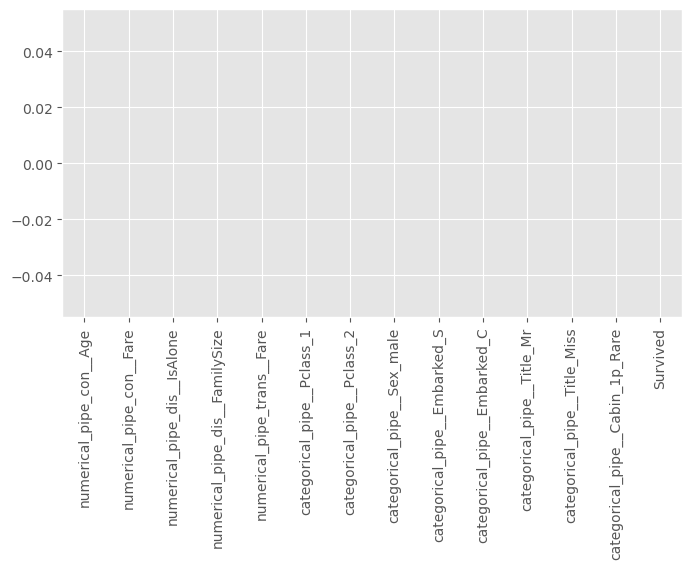

In [15]:
df.isna().mean().plot.bar(figsize=(8,4))

# Check Cardinality

In [16]:
for col in num_var:
    print('Numero de labels por variável na coluna: ' + col + ' ' + str(df[col].nunique()))

Numero de labels por variável na coluna: numerical_pipe_con__Age 83
Numero de labels por variável na coluna: numerical_pipe_con__Fare 220
Numero de labels por variável na coluna: numerical_pipe_dis__IsAlone 2
Numero de labels por variável na coluna: numerical_pipe_dis__FamilySize 9
Numero de labels por variável na coluna: numerical_pipe_trans__Fare 220
Numero de labels por variável na coluna: categorical_pipe__Pclass_1 2
Numero de labels por variável na coluna: categorical_pipe__Pclass_2 2
Numero de labels por variável na coluna: categorical_pipe__Sex_male 2
Numero de labels por variável na coluna: categorical_pipe__Embarked_S 2
Numero de labels por variável na coluna: categorical_pipe__Embarked_C 2
Numero de labels por variável na coluna: categorical_pipe__Title_Mr 2
Numero de labels por variável na coluna: categorical_pipe__Title_Miss 2
Numero de labels por variável na coluna: categorical_pipe__Cabin_1p_Rare 2
Numero de labels por variável na coluna: Survived 2


# Plots

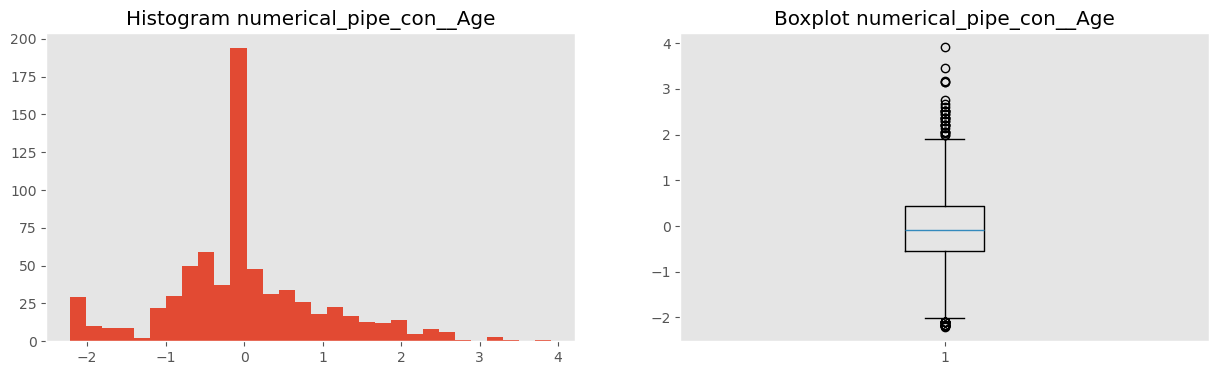

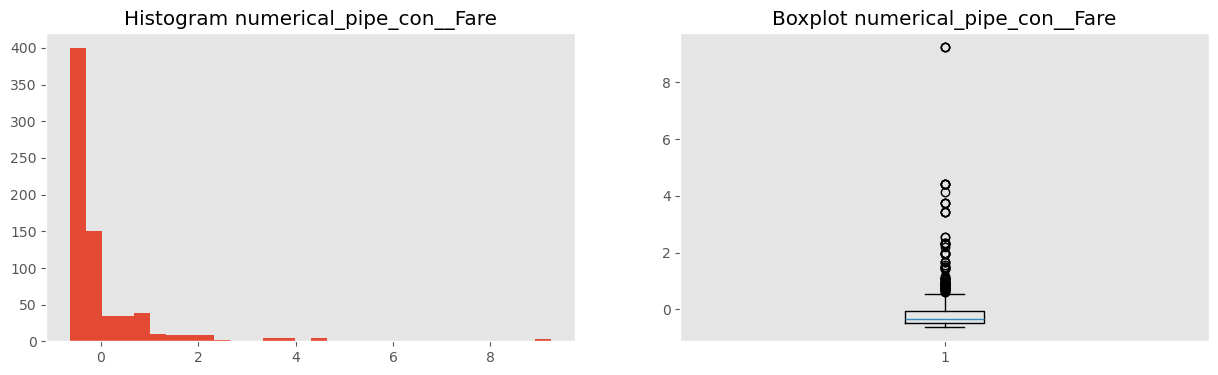

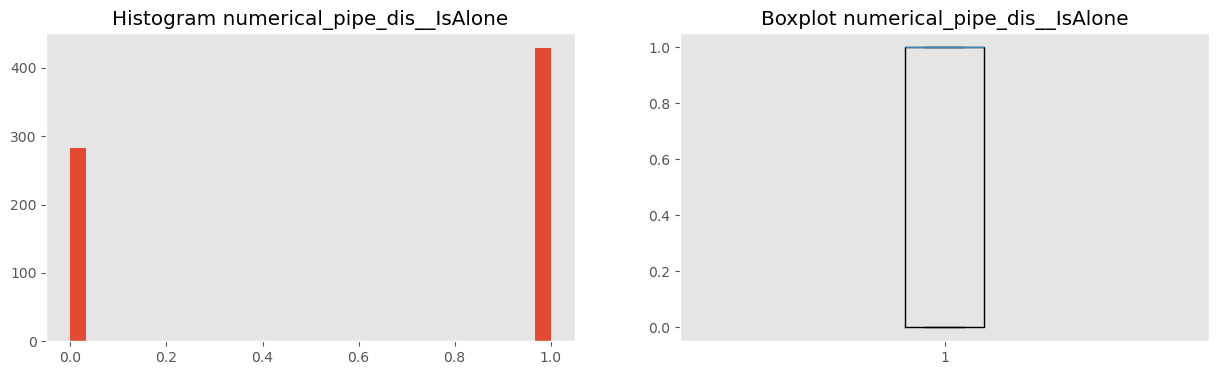

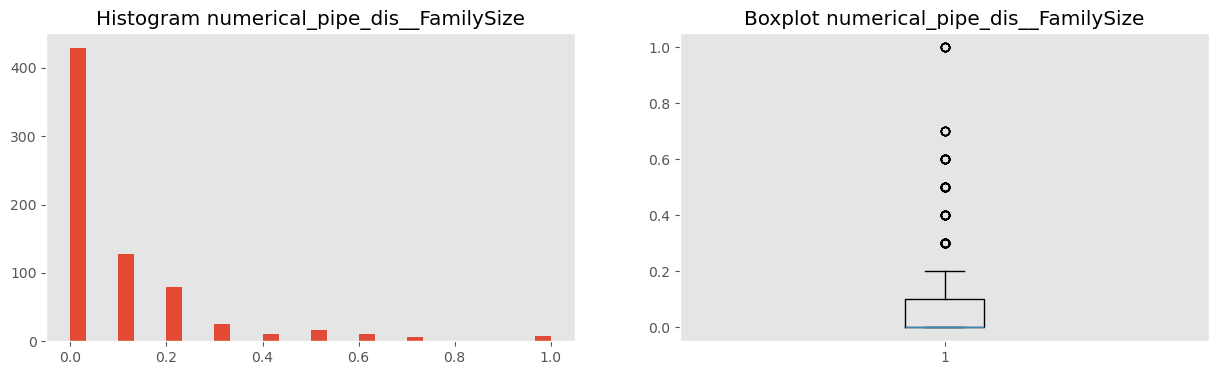

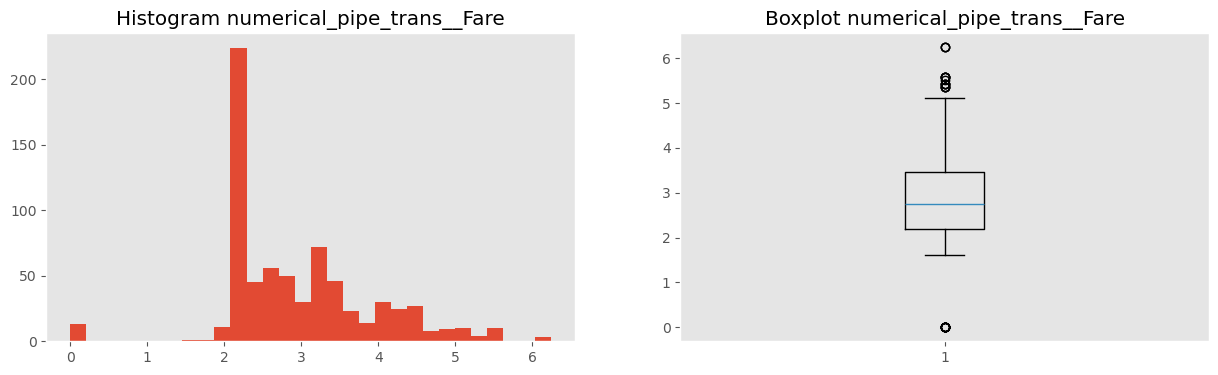

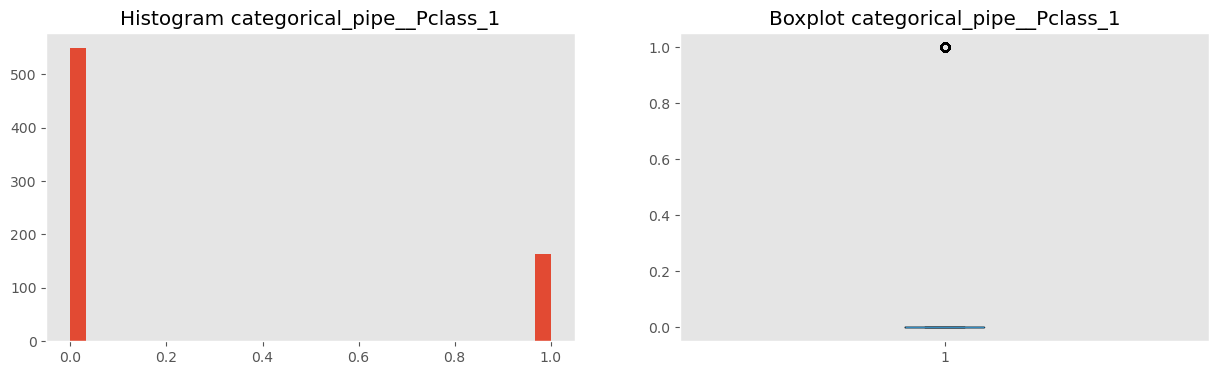

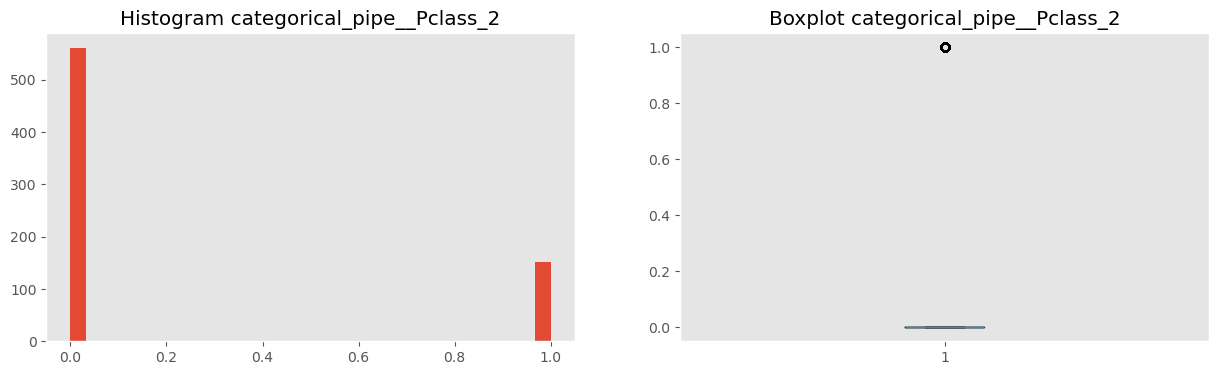

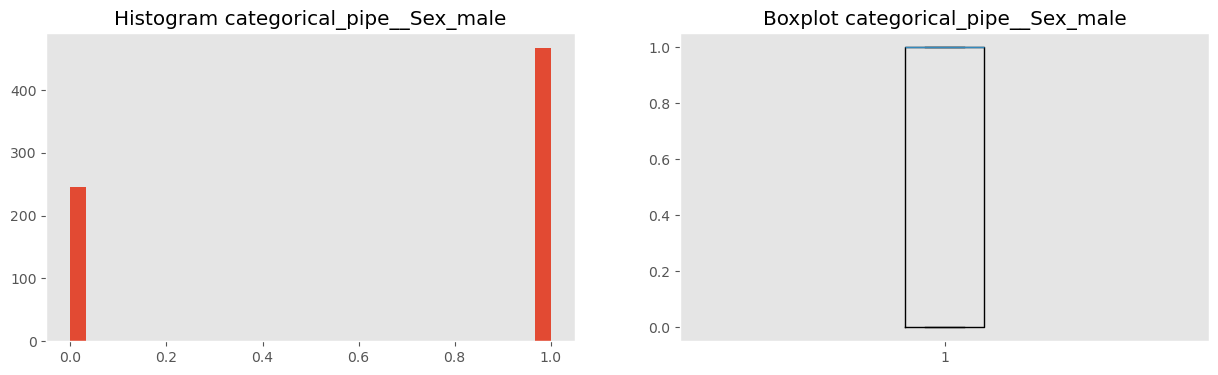

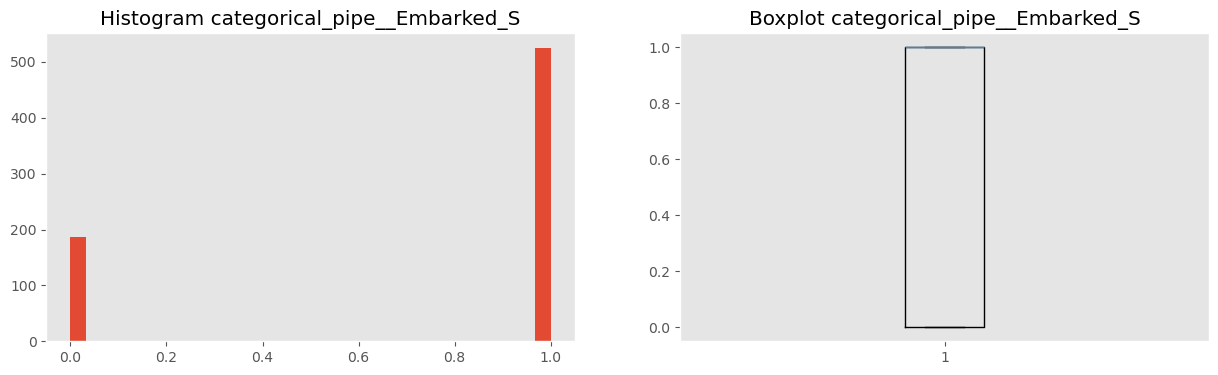

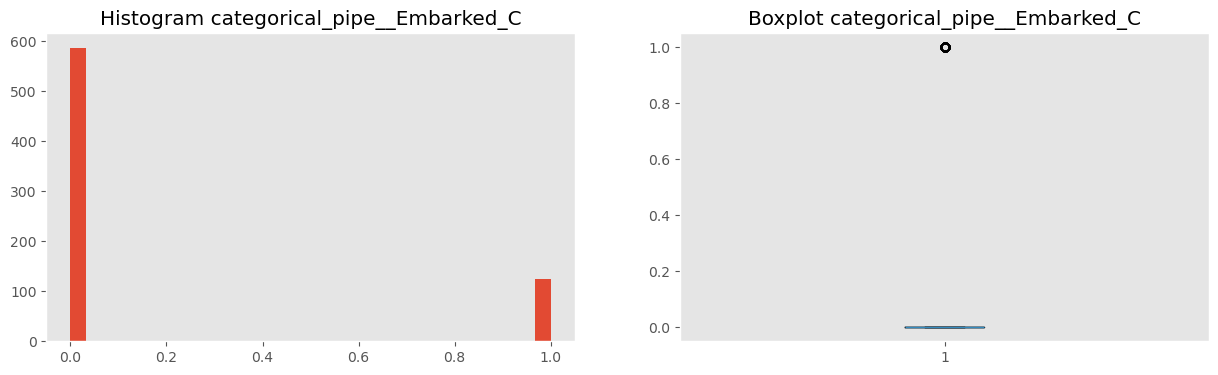

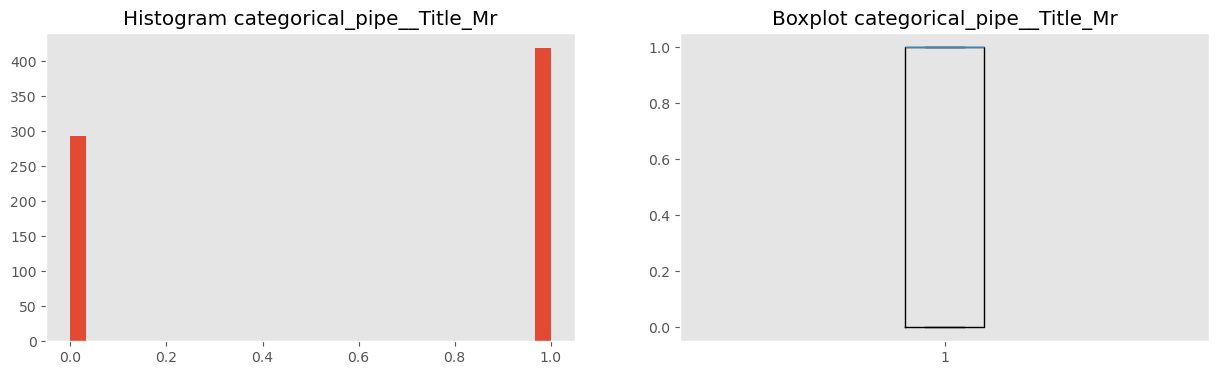

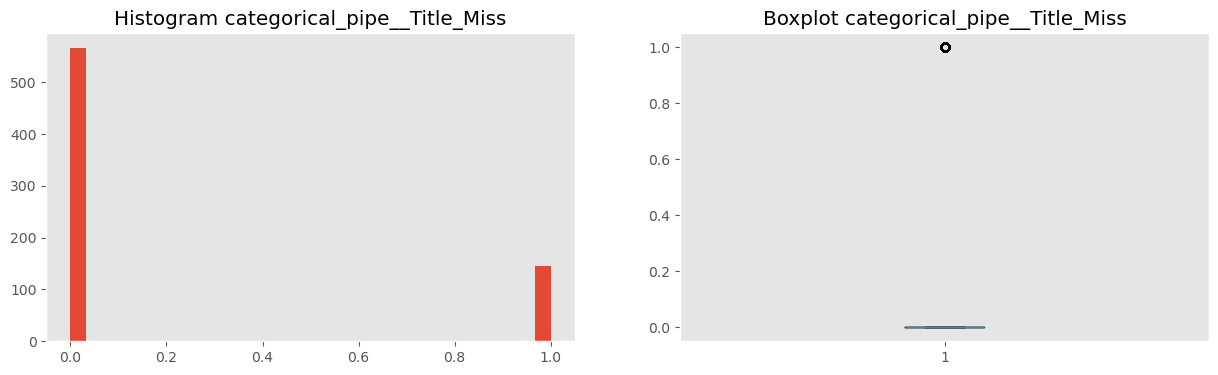

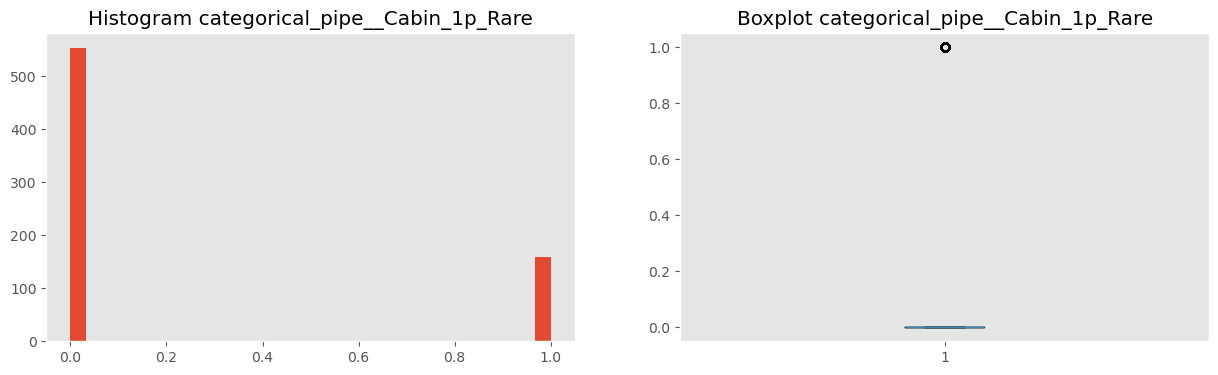

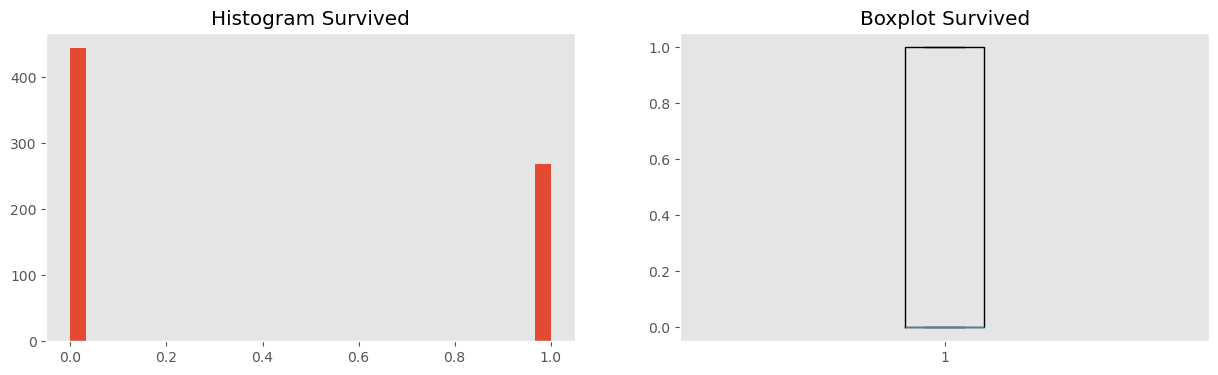

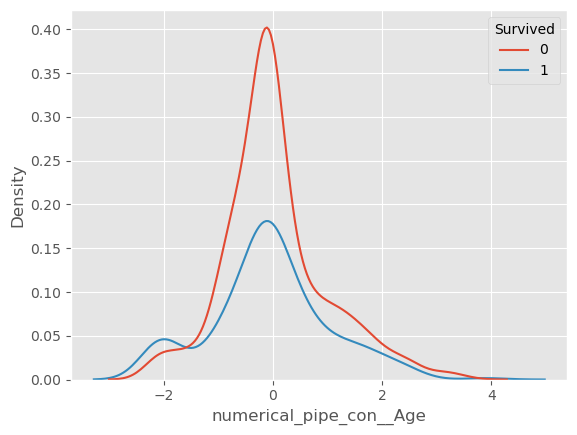

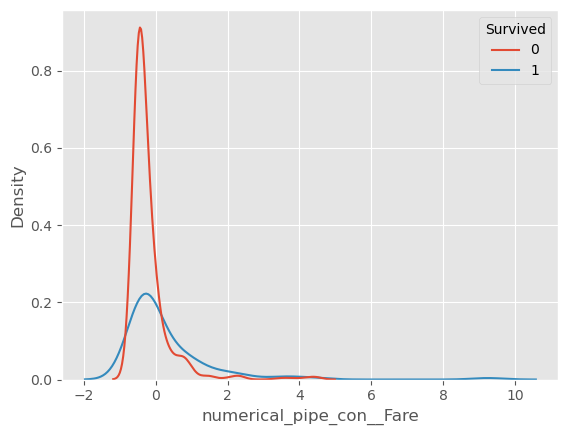

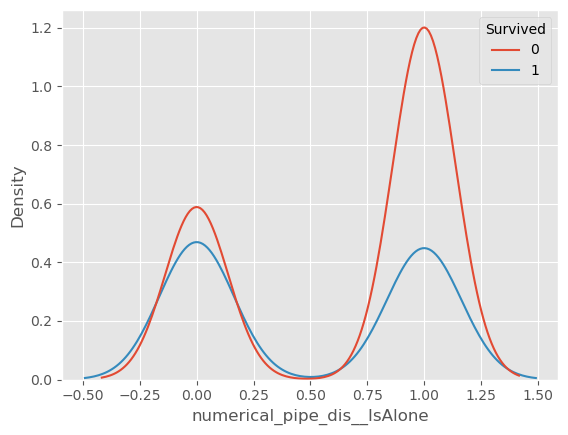

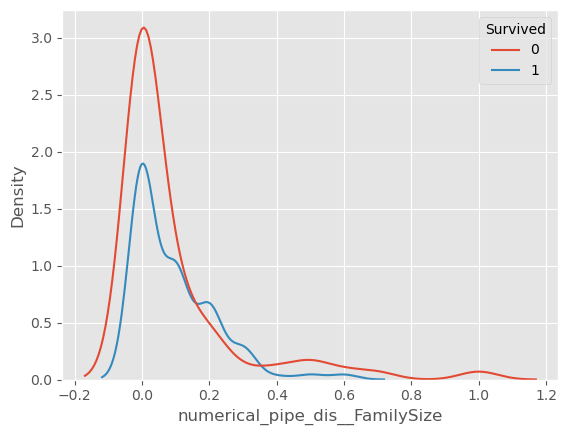

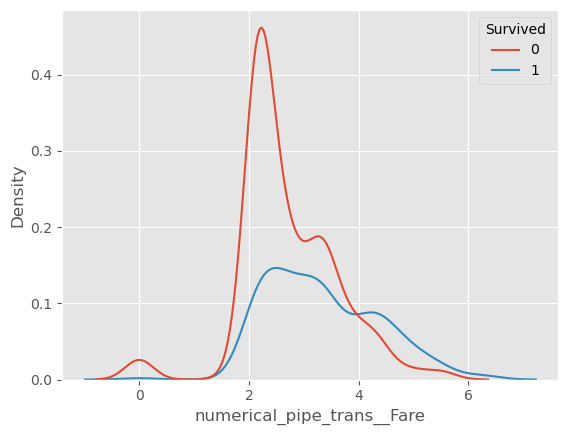

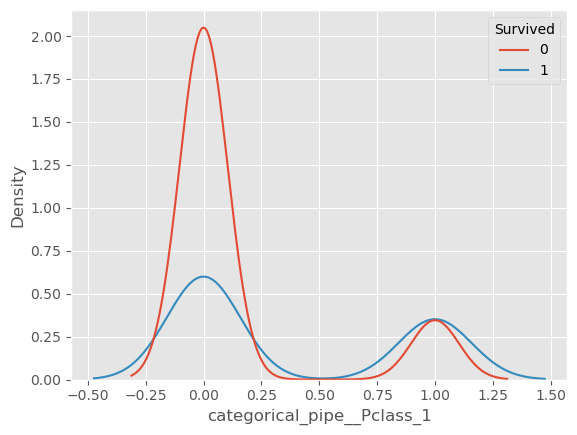

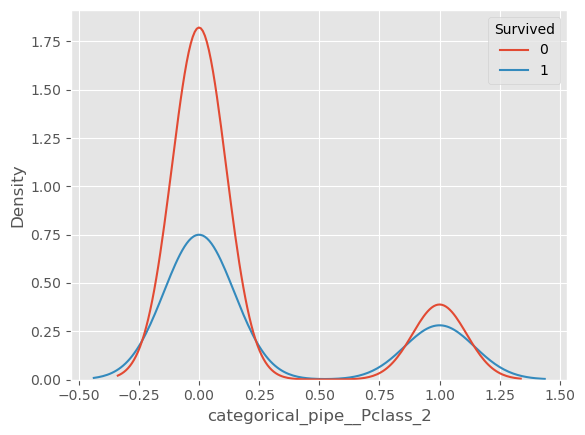

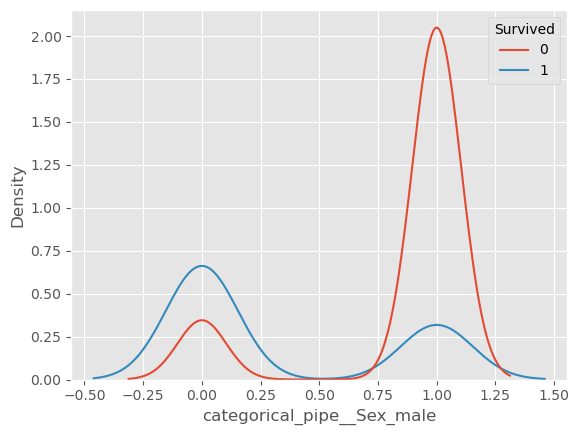

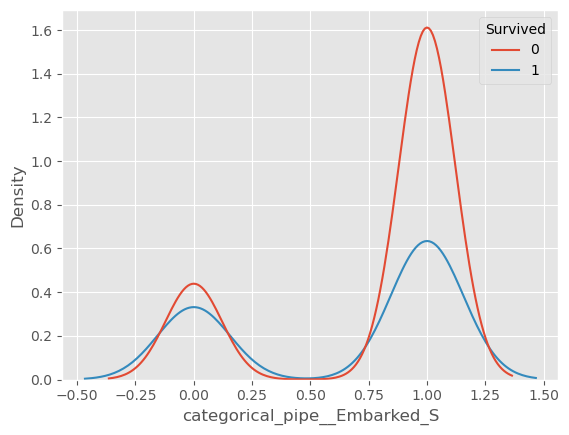

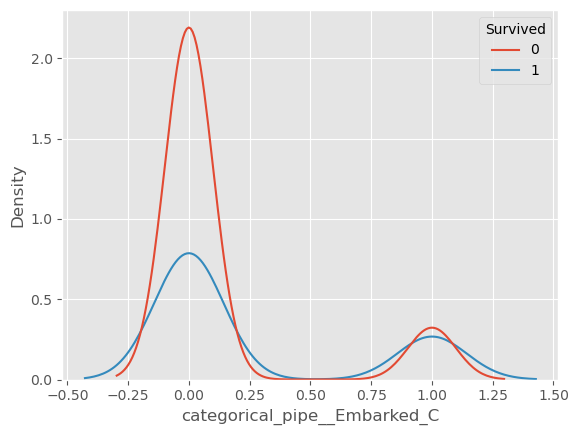

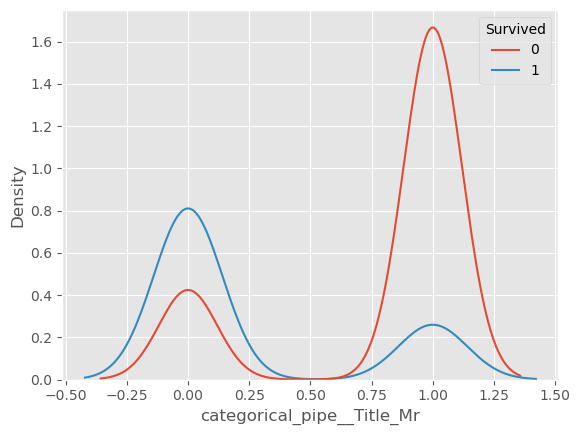

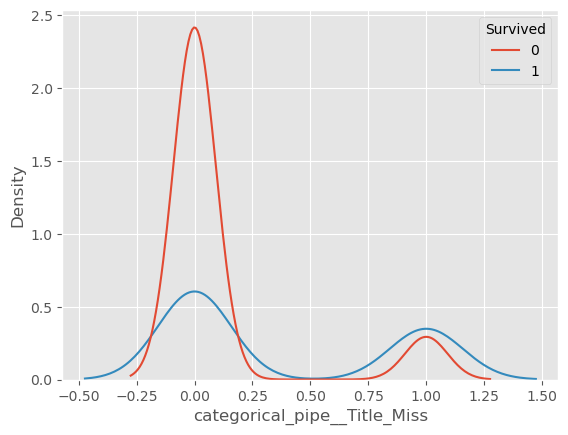

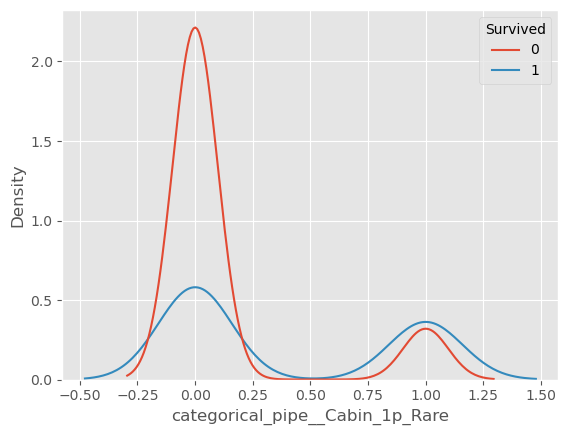

c:\Users\gustavo\Documents\Data Science\08-GitHub\kaggle\utils\plots.py:82: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


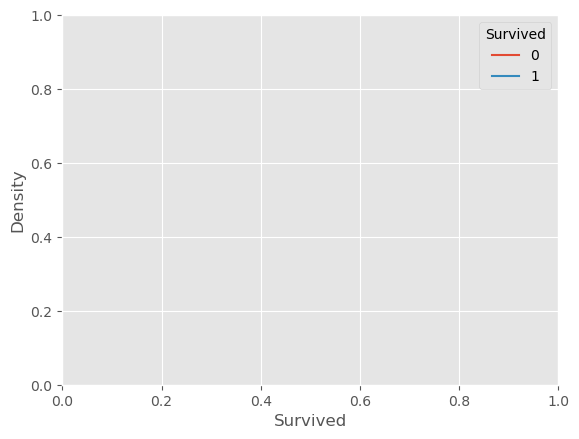

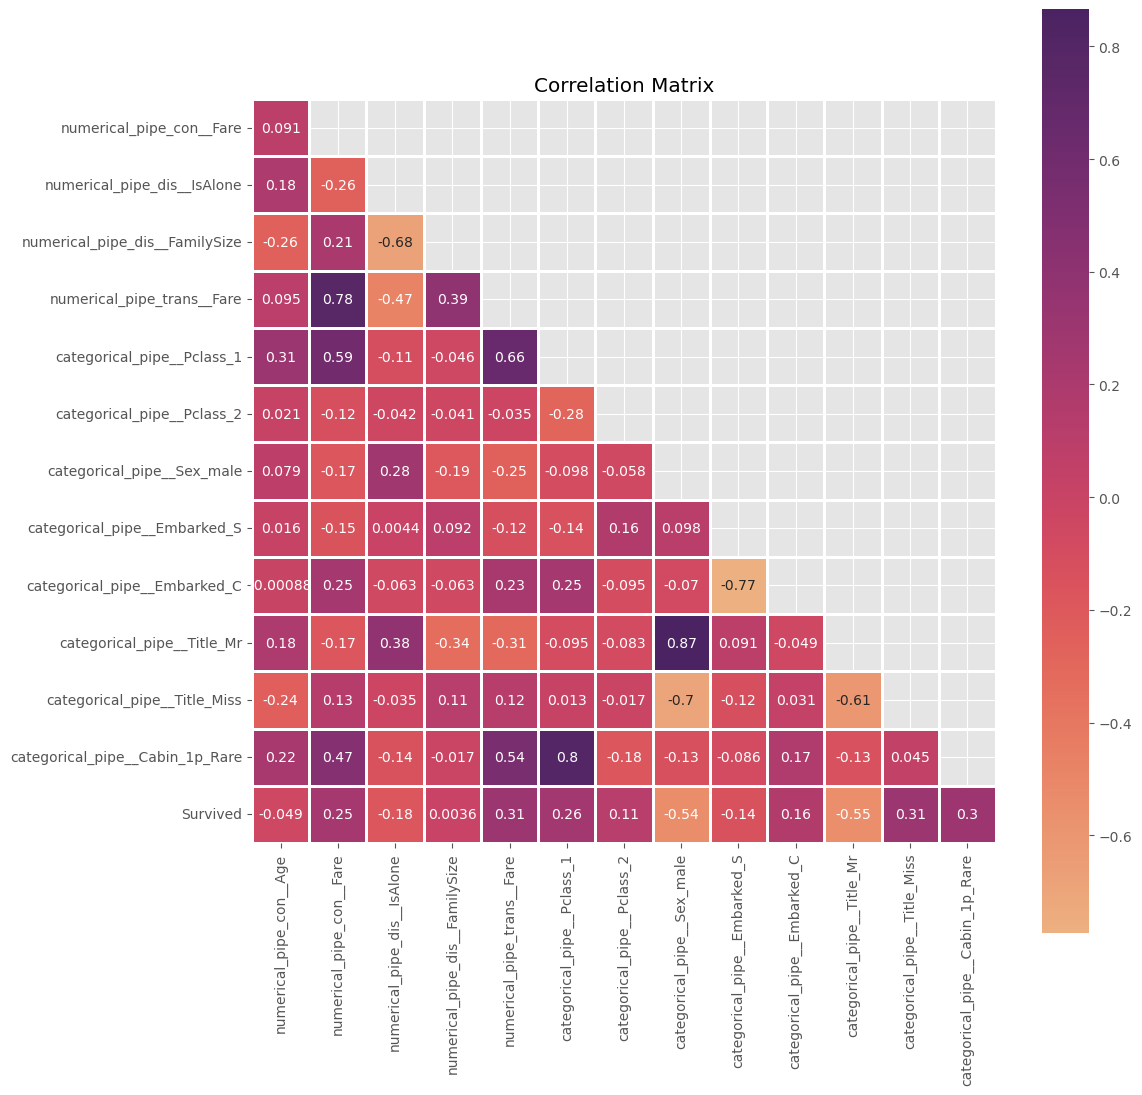

In [17]:
plot_numerical_data(df, target='Survived', classification=True)

# Correlation Analysis

In [18]:
from feature_engine.selection import DropCorrelatedFeatures, SmartCorrelatedSelection

In [19]:
sel = DropCorrelatedFeatures(
    threshold=0.8,
    method='pearson',
    missing_values='ignore'
)


# find correlated features

sel.fit(df)

DropCorrelatedFeatures()

In [20]:
sel.correlated_feature_sets_

[{'categorical_pipe__Sex_male', 'categorical_pipe__Title_Mr'}]

## SmartCorrelationSelection

### Model Performance

We will keep a feature from each correlation group based on the performance of a random forest.

In [21]:
# random forest
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=20,
)

# correlation selector
sel = SmartCorrelatedSelection(
    variables=None, # if none, selector examines all numerical variables
    method="pearson",
    threshold=0.8,
    missing_values="raise",
    selection_method="model_performance",
    estimator=rf,
    scoring="roc_auc",
    cv=3,
)

sel.fit(X_train, y_train.values.ravel())

SmartCorrelatedSelection(estimator=RandomForestClassifier(n_estimators=10,
                                                          random_state=20),
                         missing_values='raise',
                         selection_method='model_performance')

In [22]:
sel.correlated_feature_sets_

[{'categorical_pipe__Sex_male', 'categorical_pipe__Title_Mr'}]

In [23]:
sel.features_to_drop_

['categorical_pipe__Sex_male']